In [ ]:
import pandas as pd
import numpy as np
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Emotion Phrases.csv to Emotion Phrases.csv
Saving Emotion Words.csv to Emotion Words.csv


In [ ]:
import pandas as pd

phrases = pd.read_csv('Emotion Phrases.csv', header=None)
phrases.columns = ['emotion', 'text']

print('Dataset Shape:', phrases.shape)

print('\nEmotions:\n')
print(phrases['emotion'].unique())

print('\nEmotion Counts:\n')
print(phrases['emotion'].value_counts())

Dataset Shape: (7652, 2)

Emotions:

['joy' 'fear' 'anger' 'sadness' 'disgust' 'shame' 'guilt']

Emotion Counts:

emotion
anger      1094
disgust    1094
sadness    1094
shame      1094
fear       1093
joy        1092
guilt      1091
Name: count, dtype: int64


In [ ]:
print("\nSample Data:\n")

print(phrases.head())


Sample Data:

   emotion                                               text
0      joy  [ On days when I feel close to my partner and ...
1     fear  Every time I imagine that someone I love or I ...
2    anger  When I had been obviously unjustly treated and...
3  sadness  When I think about the short time that we live...
4  disgust  At a gathering I found myself involuntarily si...


In [ ]:
def clean_text(text):

    text = str(text).lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\d+','',text)

    text = re.sub(r'\s+',' ',text)

    return text.strip()


phrases['clean_text'] = phrases['text'].apply(clean_text)

print("\nCleaned Sample:\n")

print(phrases[['text','clean_text']].head())


Cleaned Sample:

                                                text  \
0  [ On days when I feel close to my partner and ...   
1  Every time I imagine that someone I love or I ...   
2  When I had been obviously unjustly treated and...   
3  When I think about the short time that we live...   
4  At a gathering I found myself involuntarily si...   

                                          clean_text  
0  on days when i feel close to my partner and ot...  
1  every time i imagine that someone i love or i ...  
2  when i had been obviously unjustly treated and...  
3  when i think about the short time that we live...  
4  at a gathering i found myself involuntarily si...  


In [ ]:
X = phrases['clean_text']

y = phrases['emotion']

print("Total Samples:",len(X))

Total Samples: 7652


In [ ]:
vectorizer = TfidfVectorizer(

    max_features=8000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True

)

X_vector = vectorizer.fit_transform(X)

print("TF-IDF Shape:",X_vector.shape)

TF-IDF Shape: (7652, 8000)


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

    X_vector,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

print("Training Data:",X_train.shape[0])

print("Testing Data:",X_test.shape[0])

Training Data: 6121
Testing Data: 1531


In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train,y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test,nb_pred)

print("\nNaive Bayes Accuracy:",nb_accuracy)


Naive Bayes Accuracy: 0.5911169170476812


In [ ]:
lr_model = LogisticRegression(

    max_iter=1500,
    C=2,
    class_weight='balanced'

)

lr_model.fit(X_train,y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test,lr_pred)

print("Logistic Accuracy:",lr_accuracy)

Logistic Accuracy: 0.6028739386022207


In [ ]:

svm_model = LinearSVC(

    C=2,
    class_weight='balanced'

)

svm_model.fit(X_train,y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test,svm_pred)

print("SVM Accuracy:",svm_accuracy)

SVM Accuracy: 0.5852384062704115


In [ ]:
print("\nMODEL COMPARISON\n")

print("Naive Bayes:",nb_accuracy)

print("Logistic:",lr_accuracy)

print("SVM:",svm_accuracy)


MODEL COMPARISON

Naive Bayes: 0.5911169170476812
Logistic: 0.6028739386022207
SVM: 0.5852384062704115


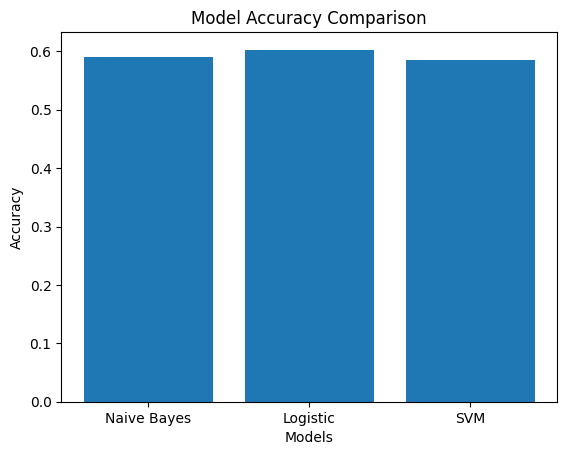

In [ ]:
models = ['Naive Bayes','Logistic','SVM']

accuracy_values = [nb_accuracy,lr_accuracy,svm_accuracy]

plt.bar(models,accuracy_values)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
print("\nClassification Report:\n")

print(classification_report(y_test,svm_pred))


Classification Report:

              precision    recall  f1-score   support

       anger       0.49      0.51      0.50       219
     disgust       0.55      0.55      0.55       219
        fear       0.68      0.73      0.70       219
       guilt       0.55      0.52      0.54       218
         joy       0.70      0.75      0.73       218
     sadness       0.60      0.58      0.59       219
       shame       0.50      0.46      0.48       219

    accuracy                           0.59      1531
   macro avg       0.58      0.59      0.58      1531
weighted avg       0.58      0.59      0.58      1531



In [ ]:
print("\n====================================")
print("   AI Emotion Detection System 🤖")
print("====================================")
while True:
    print("\n------------------------------------")
    text = input(" Enter a sentence (type 'exit' to stop): ")

    if text.lower() == "exit":
        print("\n Thank you for using Emotion AI 😊")
        print(" Program Stopped Successfully")
        break
    clean = clean_text(text)
    vector = vectorizer.transform([clean])
    prediction = svm_model.predict(vector)
    print("\n Predicted Emotion:", prediction[0])
    print("------------------------------------")


   AI Emotion Detection System 🤖

------------------------------------

 Predicted Emotion: disgust
------------------------------------

------------------------------------
